**Pertanyaan 1**

"Bagaimana tren rata-rata konsentrasi polutan PM2.5 secara bulanan di stasiun Dongsi sepanjang tahun 2015, dan pada bulan apa polusi mencapai tingkat tertinggi?"

**SMART Breakdown:**

1.   Specific : Fokus ke polutan PM2.5 di stasiun spesifik (Dongsi).

2.   Measurable : Diukur dengan angka rata-rata konsentrasi per bulan.

3.   Action-Oriented : Jika ketahuan bulan apa yang paling polutif, pemerintah/warga bisa mengambil aksi pencegahan (misal: pembatasan industri atau anjuran pakai masker di bulan tersebut).

4.   Relevant : Sangat relevan dengan tujuan analisis kualitas udara dan dampak kesehatan.

5.   Time-bound : Dibatasi hanya sepanjang tahun 2015



**Pertanyaan 2**

"Apakah terdapat korelasi antara suhu udara (TEMP) dengan kadar gas rumah kaca sulfur dioksida (SO2) di seluruh stasiun pemantauan selama periode tahun 2016?"

**SMART Breakdown:**

1.   Specific: Menguji hubungan antara variabel cuaca harian (TEMP) dan polutan spesifik (SO2).

2.   Measurable: Bisa diukur secara konkret menggunakan koefisien korelasi atau grafik scatterplot.

3.   Action-Oriented: Membantu tim analis memprediksi lonjakan zat kimia berbahaya berdasarkan perubahan suhu/musim.

4.  Relevant: Relevan untuk memahami pola penyebaran polusi akibat faktor alam.

5.  Time-bound: Dibatasi khusus pada data tahun 2016.

# **A. Gathering Data**

In [1]:
import pandas as pd
import glob

# Mengambil semua file yang berakhiran .csv di direktori utama Colab
path_files = glob.glob('*.csv')

# Menggabungkan semua file CSV menjadi satu DataFrame
df_list = [pd.read_csv(file) for file in path_files]
air_quality_df = pd.concat(df_list, ignore_index=True)

# Cek jumlah baris data yang berhasil digabungkan
print(f"Total data dari seluruh stasiun: {air_quality_df.shape[0]} baris")
air_quality_df.head()

Total data dari seluruh stasiun: 376982 baris


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013.0,3.0,1.0,0.0,5.0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Nongzhanguan
1,2,2013.0,3.0,1.0,1.0,8.0,12.0,6.0,14.0,200.0,84.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Nongzhanguan
2,3,2013.0,3.0,1.0,2.0,3.0,6.0,5.0,14.0,200.0,83.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Nongzhanguan
3,4,2013.0,3.0,1.0,3.0,5.0,5.0,5.0,14.0,200.0,84.0,-1.4,1026.2,-25.5,0.0,N,4.9,Nongzhanguan
4,5,2013.0,3.0,1.0,4.0,5.0,5.0,6.0,21.0,200.0,77.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Nongzhanguan


# **B. Assesing Data**

In [2]:
# Untuk melihat tipe data dan jumlah data non-null di setiap kolom
air_quality_df.info()

# Untuk melihat jumlah total data yang bolong/kosong di setiap kolom
air_quality_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376982 entries, 0 to 376981
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       376982 non-null  int64  
 1   year     376981 non-null  float64
 2   month    376981 non-null  float64
 3   day      376980 non-null  float64
 4   hour     376980 non-null  float64
 5   PM2.5    369101 non-null  float64
 6   PM10     371144 non-null  float64
 7   SO2      368816 non-null  float64
 8   NO2      366192 non-null  float64
 9   CO       357078 non-null  float64
 10  O3       364717 non-null  float64
 11  TEMP     376621 non-null  float64
 12  PRES     376626 non-null  float64
 13  DEWP     376616 non-null  float64
 14  RAIN     376629 non-null  float64
 15  wd       375355 non-null  object 
 16  WSPM     376689 non-null  float64
 17  station  376980 non-null  object 
dtypes: float64(15), int64(1), object(2)
memory usage: 51.8+ MB


,0
No,0
year,1
month,1
day,2
hour,2
PM2.5,7881
PM10,5838
SO2,8166
NO2,10790
CO,19904


In [3]:
# 1. Mengecek statistik deskriptif untuk melihat potensi Outlier
print("=== STATISTIK DESKRIPTIF (Cek Outlier) ===")
display(air_quality_df[['PM2.5', 'PM10', 'SO2', 'TEMP']].describe())

# 2. Mengecek jumlah Data Ganda (Duplicate)
print("\n=== CEK DATA DUPLIKAT ===")
duplicate_count = air_quality_df.duplicated().sum()
print(f"Jumlah data duplikat: {duplicate_count} baris")

=== STATISTIK DESKRIPTIF (Cek Outlier) ===


,PM2.5,PM10,SO2,TEMP
count,369101.000000,371144.000000,368816.000000,376621.000000
mean,79.605338,104.398368,16.095843,13.685881
std,80.115829,91.225527,22.058568,11.427756
min,2.000000,2.000000,0.285600,-19.900000
25%,21.000000,36.000000,3.000000,3.300000
50%,55.000000,82.000000,7.000000,14.800000
75%,111.000000,145.000000,20.000000,23.400000
max,941.000000,999.000000,500.000000,41.600000



=== CEK DATA DUPLIKAT ===
Jumlah data duplikat: 0 baris


# **C. Cleaning Data**

In [4]:
# 1. Mengatasi Missing Values dengan metode Forward Fill (mengisi dengan nilai jam sebelumnya)
air_quality_df.ffill(inplace=True)

# Jika masih ada sisa kosong di baris paling awal sekali, isi dengan nilai setelahnya (Backward Fill)
air_quality_df.bfill(inplace=True)

# 2. Menggabungkan kolom year, month, day, hour menjadi satu kolom datetime standar
air_quality_df['datetime'] = pd.to_datetime(air_quality_df[['year', 'month', 'day', 'hour']])

# 3. Memastikan data benar-benar sudah bersih 100%
print("=== PENGECEKAN ULANG SETELAH CLEANING ===")
print(f"Jumlah missing values sekarang: {air_quality_df.isnull().sum().sum()}")

=== PENGECEKAN ULANG SETELAH CLEANING ===
Jumlah missing values sekarang: 0


# **D. Tahap Exploratory Data Analysis (EDA)**

In [5]:
# ==============================================================================
# EDA UNTUK PERTANYAAN 1: Tren Bulanan PM2.5 di Dongsi (2015)
# ==============================================================================
# Filter data untuk stasiun Dongsi di tahun 2015
df_dongsi_2015 = air_quality_df[(air_quality_df['station'] == 'Dongsi') & (air_quality_df['year'] == 2015)]

# Grouping berdasarkan bulan dan ambil rata-rata PM2.5
eda_tren_bulanan = df_dongsi_2015.groupby('month')['PM2.5'].mean().reset_index()

print("=== HASIL EDA PERTANYAAN 1 ===")
print(eda_tren_bulanan)
print("\n" + "="*50 + "\n")

# ==============================================================================
# EDA UNTUK PERTANYAAN 2: Korelasi Suhu (TEMP) dan SO2 (2016)
# ==============================================================================
# Filter data khusus tahun 2016
df_2016 = air_quality_df[air_quality_df['year'] == 2016]

# Menghitung angka korelasi (Korelasi Pearson) antara TEMP dan SO2
korelasi = df_2016['TEMP'].corr(df_2016['SO2'])

print("=== HASIL EDA PERTANYAAN 2 ===")
print(f"Angka Korelasi antara TEMP dan SO2 di tahun 2016 adalah: {korelasi}")

=== HASIL EDA PERTANYAAN 1 ===
    month       PM2.5
0     1.0  101.215860
1     2.0  108.953869
2     3.0   93.386156
3     4.0   77.606944
4     5.0   58.028226
5     6.0   66.686111
6     7.0   69.162634
7     8.0   49.767473
8     9.0   54.518056
9    10.0   80.030914
10   11.0  125.302778
11   12.0  161.241935


=== HASIL EDA PERTANYAAN 2 ===
Angka Korelasi antara TEMP dan SO2 di tahun 2016 adalah: -0.32157133166276414


In [6]:
air_quality_df.groupby('month')['PM2.5'].mean()

,PM2.5
month,
1.0,93.367288
2.0,91.569038
3.0,95.136712
4.0,74.316881
5.0,65.035117
6.0,69.748299
7.0,72.288609
8.0,53.994167
9.0,61.732092


In [7]:
air_quality_df['TEMP'].corr(air_quality_df['SO2'])

np.float64(-0.3117828119615064)

In [8]:
air_quality_df[(air_quality_df['station'] == 'Dongsi') & (air_quality_df['year'] == 2015)]

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
204944,16105,2015.0,1.0,1.0,0.0,3.0,14.0,15.0,29.0,600.0,33.0,-7.0,1026.0,-23.8,0.0,ENE,0.9,Dongsi,2015-01-01 00:00:00
204945,16106,2015.0,1.0,1.0,1.0,5.0,27.0,14.0,33.0,700.0,28.0,-2.0,1030.0,-22.0,0.0,NW,3.0,Dongsi,2015-01-01 01:00:00
204946,16107,2015.0,1.0,1.0,2.0,4.0,25.0,11.0,31.0,600.0,27.0,-4.0,1031.0,-22.1,0.0,ENE,2.1,Dongsi,2015-01-01 02:00:00
204947,16108,2015.0,1.0,1.0,3.0,3.0,26.0,8.0,27.0,400.0,25.0,-4.0,1028.0,-22.6,0.0,N,1.4,Dongsi,2015-01-01 03:00:00
204948,16109,2015.0,1.0,1.0,4.0,4.0,15.0,8.0,27.0,500.0,36.0,-4.0,1029.0,-22.6,0.0,N,1.6,Dongsi,2015-01-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213699,24860,2015.0,12.0,31.0,19.0,119.0,127.0,23.0,84.0,2300.0,2.0,-1.4,1026.3,-8.6,0.0,E,1.0,Dongsi,2015-12-31 19:00:00
213700,24861,2015.0,12.0,31.0,20.0,140.0,143.0,27.0,86.0,2300.0,2.0,-2.5,1026.2,-8.4,0.0,E,1.3,Dongsi,2015-12-31 20:00:00
213701,24862,2015.0,12.0,31.0,21.0,157.0,184.0,29.0,91.0,2800.0,3.0,-2.7,1025.8,-8.0,0.0,ENE,0.9,Dongsi,2015-12-31 21:00:00
213702,24863,2015.0,12.0,31.0,22.0,171.0,209.0,37.0,104.0,3800.0,4.0,-3.5,1025.5,-7.6,0.0,ENE,0.4,Dongsi,2015-12-31 22:00:00


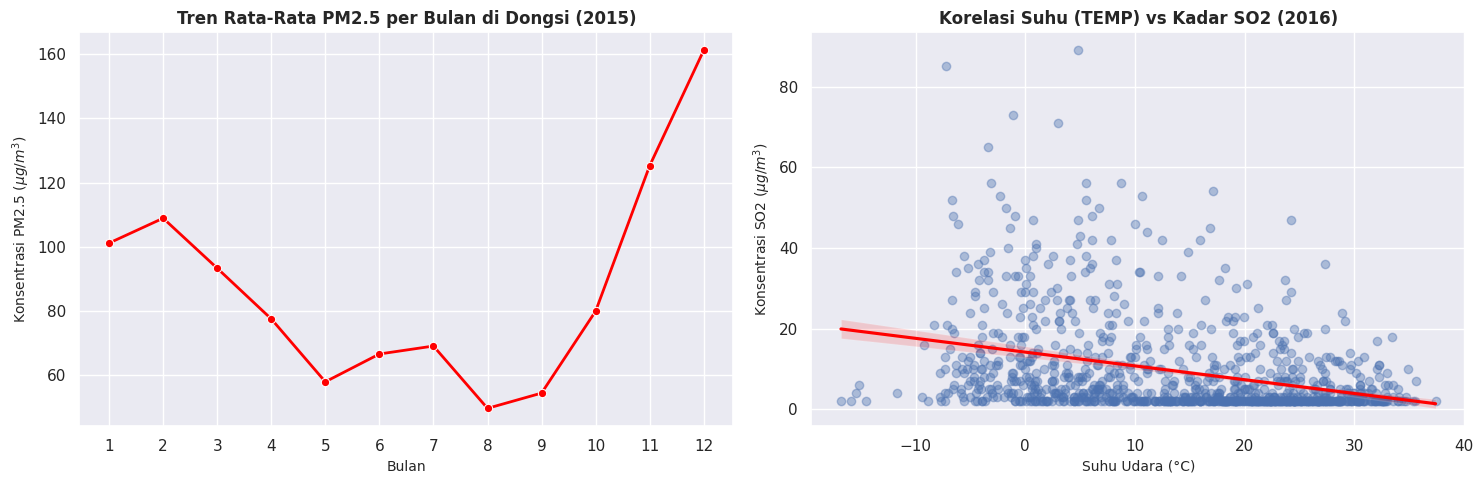

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Atur gaya visualisasi agar rapi
sns.set_theme(style="darkgrid")
plt.figure(figsize=(15, 5))

# ------------------------------------------------------------------------------
# GRAFIK 1: Line Chart untuk Tren Bulanan PM2.5 (Pertanyaan 1)
# ------------------------------------------------------------------------------
plt.subplot(1, 2, 1)
sns.lineplot(data=eda_tren_bulanan, x='month', y='PM2.5', marker='o', color='red', linewidth=2)
plt.title('Tren Rata-Rata PM2.5 per Bulan di Dongsi (2015)', fontsize=12, fontweight='bold')
plt.xlabel('Bulan', fontsize=10)
# Menggunakan raw string (r'...') untuk menghindari SyntaxWarning escape sequence
plt.ylabel(r'Konsentrasi PM2.5 ($\mu g/m^3$)', fontsize=10)
plt.xticks(range(1, 13))

# ------------------------------------------------------------------------------
# GRAFIK 2: Scatter Plot untuk Korelasi TEMP vs SO2 (Pertanyaan 2)
# ------------------------------------------------------------------------------
plt.subplot(1, 2, 2)
# Kita ambil sampel 1000 data saja agar grafik tidak terlalu padat dan berat dijalankan
df_sample = df_2016.sample(1000, random_state=42)
sns.regplot(data=df_sample, x='TEMP', y='SO2', scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title('Korelasi Suhu (TEMP) vs Kadar SO2 (2016)', fontsize=12, fontweight='bold')
plt.xlabel('Suhu Udara (°C)', fontsize=10)
# Menggunakan raw string (r'...') untuk menghindari SyntaxWarning escape sequence
plt.ylabel(r'Konsentrasi SO2 ($\mu g/m^3$)', fontsize=10)

plt.tight_layout()
plt.show()

# **Kesimpulan**
1. Pola musiman mempengaruhi peningkatan polusi PM2.5 dimana:
*   Kadar PM2.5 melonjak pada akhir dan awal tahun (puncaknya ada di Musim Dingin dimana kada PM2.5 di bulan Desember mencapai rata-rata tertinggi sebesar 161.24 $\mu\text{g/m}^3$)
*   cenderung menurun dan berada di titik terendah pada pertengahan tahun (Musim Panas), khususnya pada bulan Agustus yang menyentuh angka terendah yaitu 49.76 $\mu\text{g/m}^3$.
2. Terdapat korelasi negatif yang lemah hingga moderat antara suhu udara dan konsentrasi $\text{SO}_2$. Semakin rendah suhu udara (dingin), konsentrasi gas $\text{SO}_2$ di udara cenderung meningkat. Sebaliknya, saat suhu udara tinggi (panas), konsentrasi $\text{SO}_2$ cenderung lebih rendah dan melandai (sebagaimana ditunjukkan oleh garis tren merah yang menurun).
3. Hubungan antara tren PM2.5 yang tinggi di musim dingin dan korelasi negatif $\text{SO}_2$ terhadap suhu dapat memperburuk kualitas udara. Hal ini kemungkinan besar dipengaruhi oleh faktor meteorologi (seperti inversi suhu yang menjebak polutan) atau meningkatnya aktivitas pemanas ruangan berbahan bakar fosil (seperti batu bara) selama musim dingin di wilayah tersebut